# 🚲 Bike Sharing Rental — DS Group 6

**Problem Statement:**
Analyze the bike rental dataset to identify key factors affecting bike demand (weather, time, season) and build a predictive regression model to forecast hourly rental demand.

---

# **`Exploratory Data Analysis (EDA)`**

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load Dataset

In [ ]:
df = pd.read_csv('Dataset.csv')
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset contains 17379 rows and 17 columns


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [ ]:
print("Last 5 Rows:")
df.tail()

Last 5 Rows:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,31-12-2012,springer,2012,12,19,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,11,108,119
17375,17376,31-12-2012,springer,2012,12,20,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,8,81,89
17376,17377,31-12-2012,springer,2012,12,21,No,1,Working Day,Clear,?,0.2576,0.6,0.1642,7,83,90
17377,17378,31-12-2012,springer,2012,12,22,No,1,Working Day,Clear,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,31-12-2012,springer,2012,12,23,No,1,?,Clear,0.26,0.2727,0.65,0.1343,12,37,49


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


In [ ]:
df.describe()

,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


## 3. Data Cleaning

### 3.1 Handling Categorical Inconsistencies

In [ ]:
# Replace invalid entries and fix incorrect labels
df.replace('?', np.nan, inplace=True)

cat_cols = df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

df.replace(['nan', 'NaN', ' NAN'], np.nan, inplace=True)
df['season'] = df['season'].replace('springer', 'spring')
df['weathersit'] = df['weathersit'].replace({'lightrain': 'light rain'})
print("Categorical inconsistencies fixed!")

Categorical inconsistencies fixed!


### 3.2 Data Type Correction

In [ ]:
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)

categorical_cols = ['season','yr','mnth','holiday','weekday','workingday','weathersit']
for col in categorical_cols:
    df[col] = df[col].astype('category')

num_cols = ['temp','atemp','hum','windspeed','casual','registered','cnt']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types corrected!")

Data types corrected!


### 3.3 Missing Values

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])
missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"\nTotal Missing: {df.isnull().sum().sum()} ({missing_pct:.4f}%)")
df = df.dropna()
print(f"Rows after dropping: {len(df)}")

Missing values per column:
season         6
yr             1
mnth           1
holiday        1
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
dtype: int64

Total Missing: 48 (0.0162%)
Rows after dropping: 17339


> **Note:** Missing values were less than 0.01% — safely dropped without impacting analysis.

### 3.4 Duplicates

In [ ]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


### 3.5 Remove Irrelevant Features

In [ ]:
if 'instant' in df.columns:
    df = df.drop('instant', axis=1)
    print("'instant' column dropped — it is a unique identifier with no predictive value.")
print("Final Shape:", df.shape)

'instant' column dropped — it is a unique identifier with no predictive value.
Final Shape: (17339, 16)


### 3.6 Outlier Detection

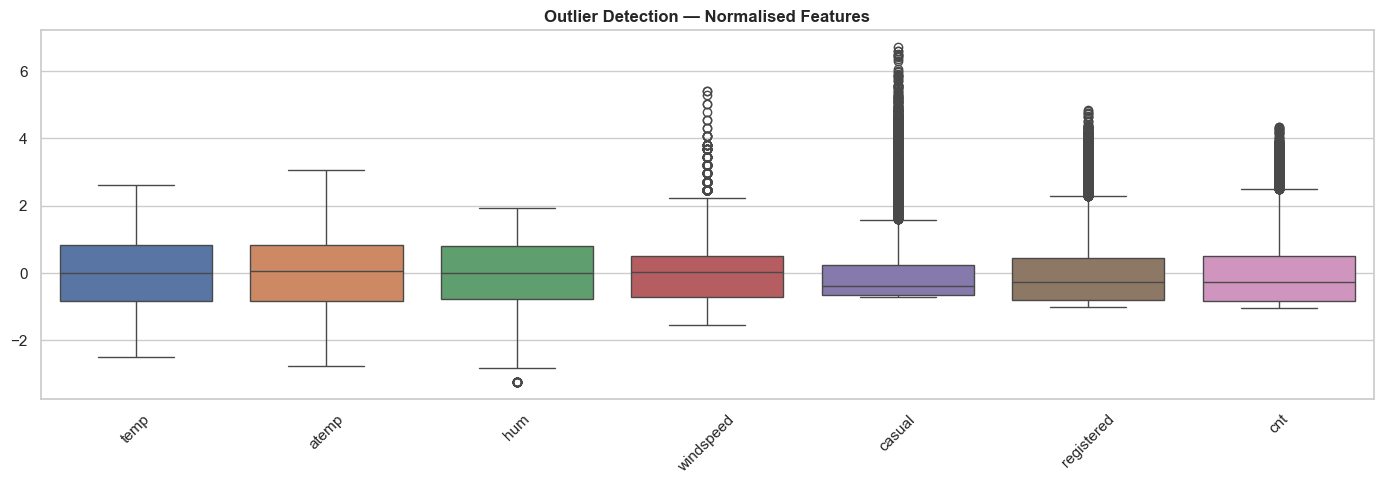

In [ ]:
from sklearn.preprocessing import StandardScaler as _sc

_scaler = _sc()
_num = ['temp','atemp','hum','windspeed','casual','registered','cnt']
_scaled = pd.DataFrame(_scaler.fit_transform(df[_num]), columns=_num)

plt.figure(figsize=(14, 5))
sns.boxplot(data=_scaled)
plt.xticks(rotation=45)
plt.title("Outlier Detection — Normalised Features", fontweight='bold')
plt.tight_layout()
plt.show()

> **Outlier Strategy:** Outliers in `cnt`, `casual`, and `registered` represent genuine high-demand events (holidays, good weather). Retained intentionally — they carry valuable business signal.

## 4. Univariate Analysis

### 4.1 Numerical Features — Distribution

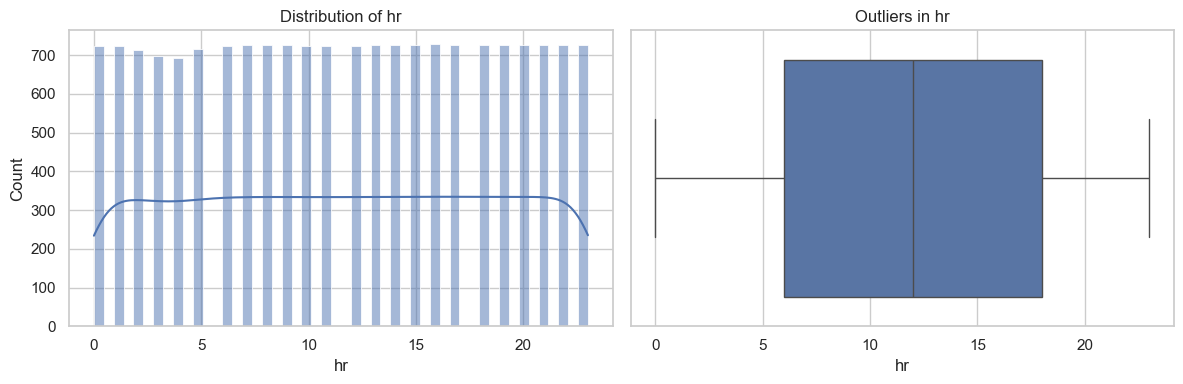

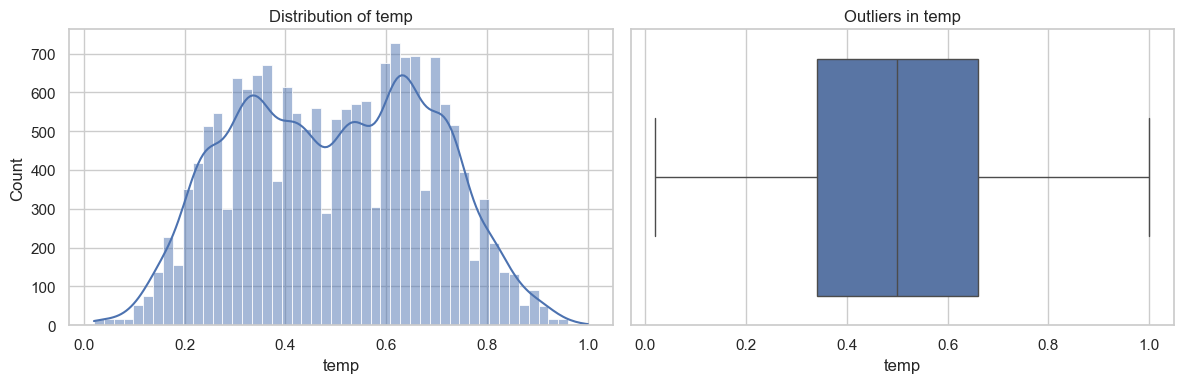

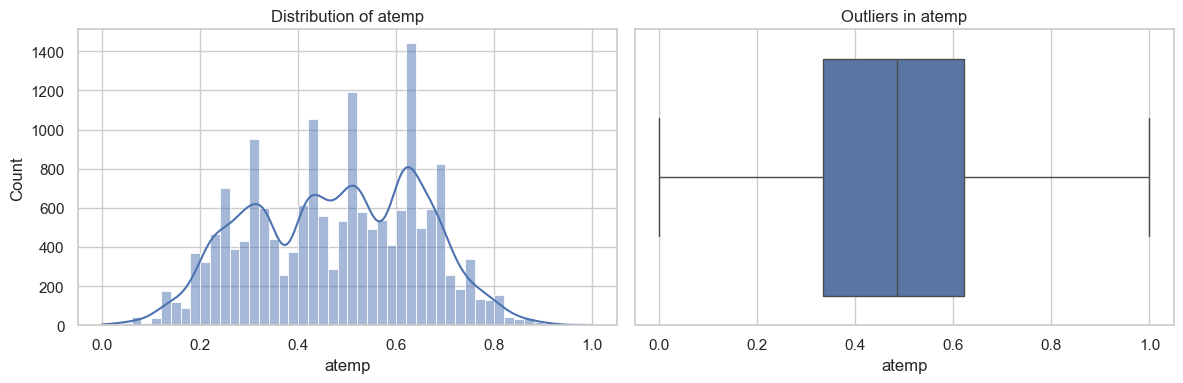

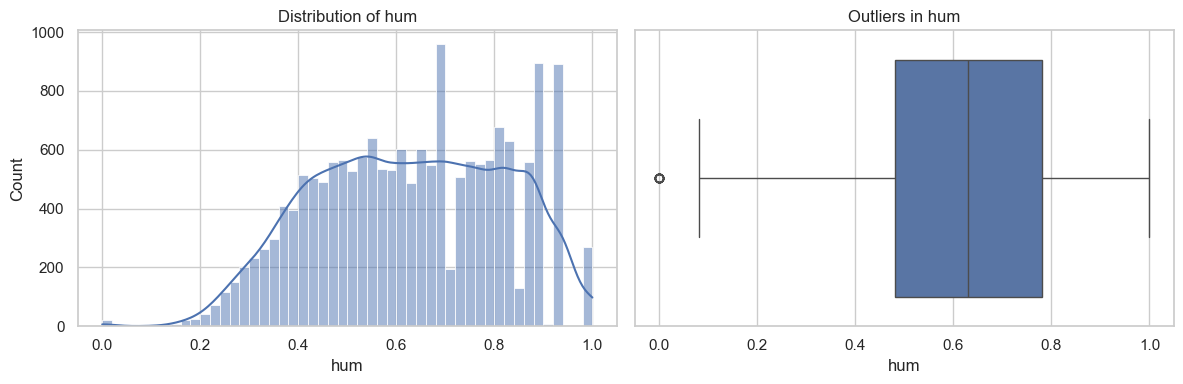

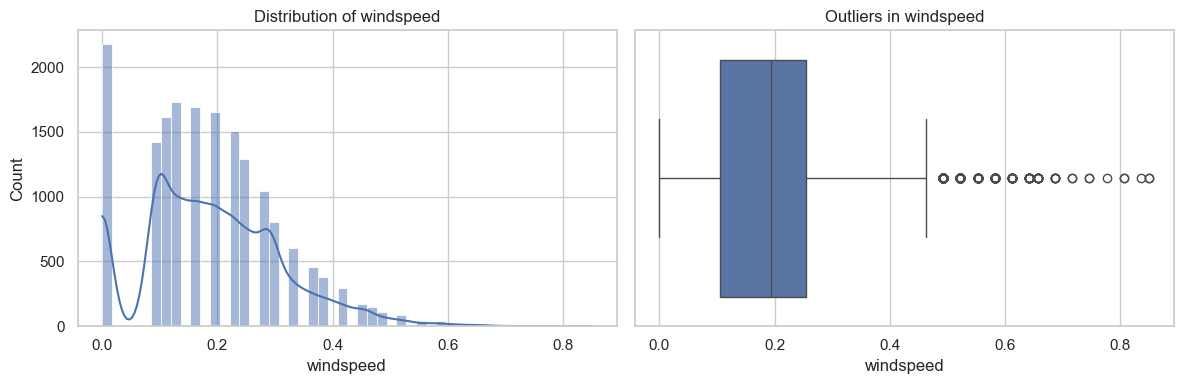

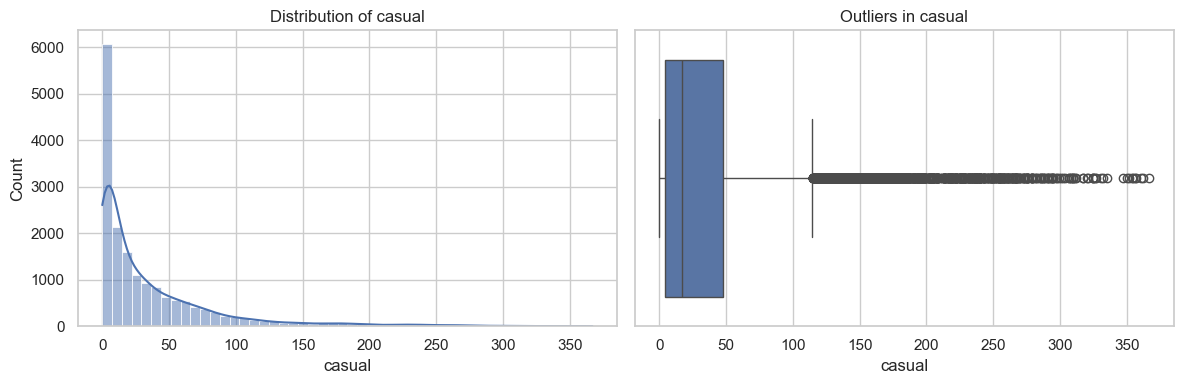

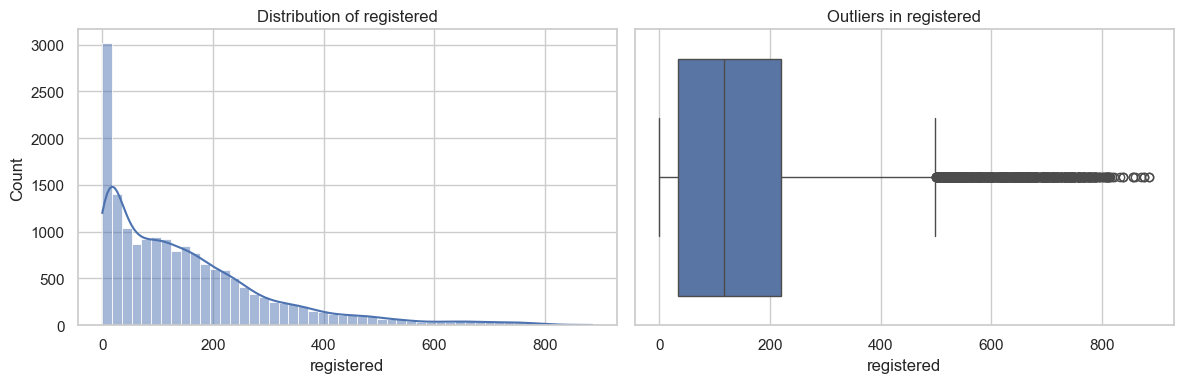

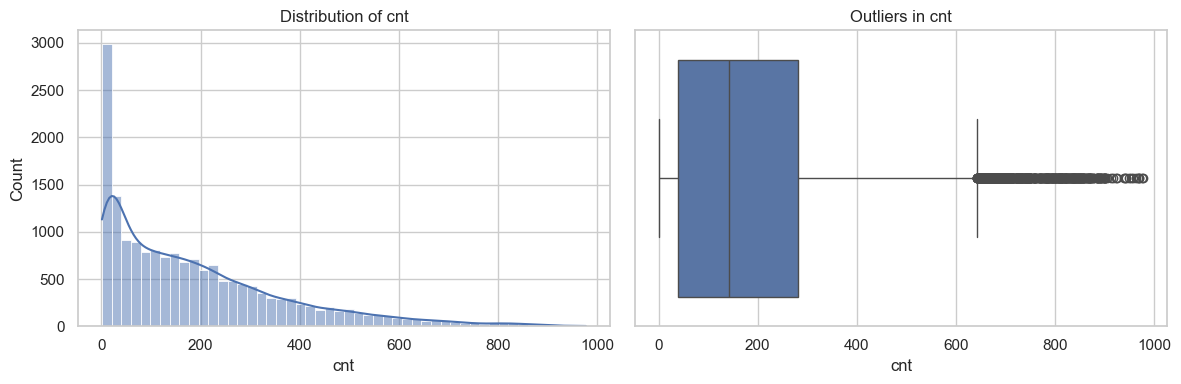

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Outliers in {col}')
    plt.tight_layout()
    plt.show()

### 4.2 Categorical Features

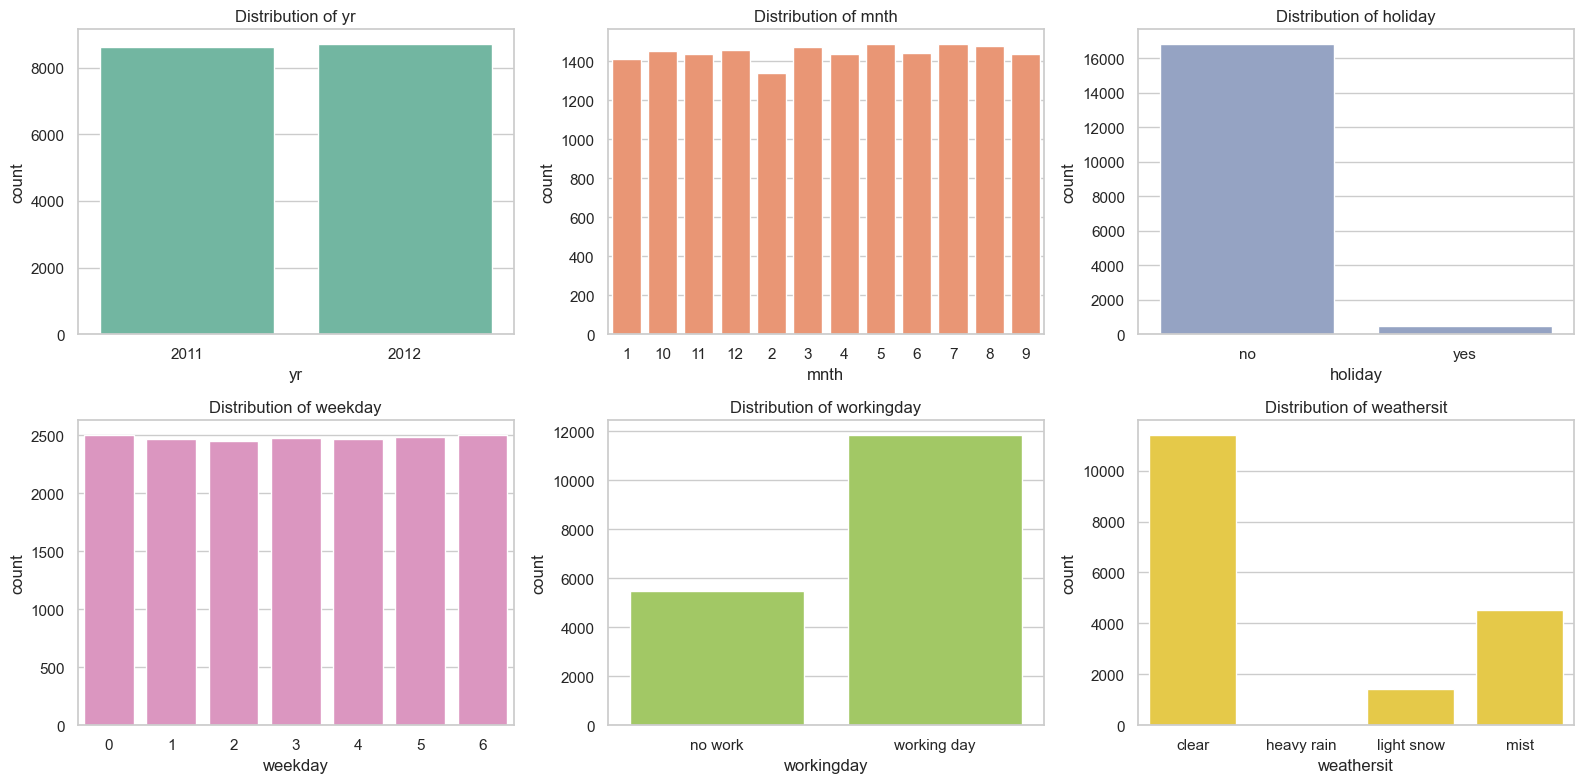

In [ ]:
cat_cols = ['yr','mnth','holiday','weekday','workingday','weathersit']
n_rows = math.ceil(len(cat_cols) / 3)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()
palette = sns.color_palette("Set2", len(cat_cols))

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i], color=palette[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.3 Target Variable — Bike Demand (cnt)

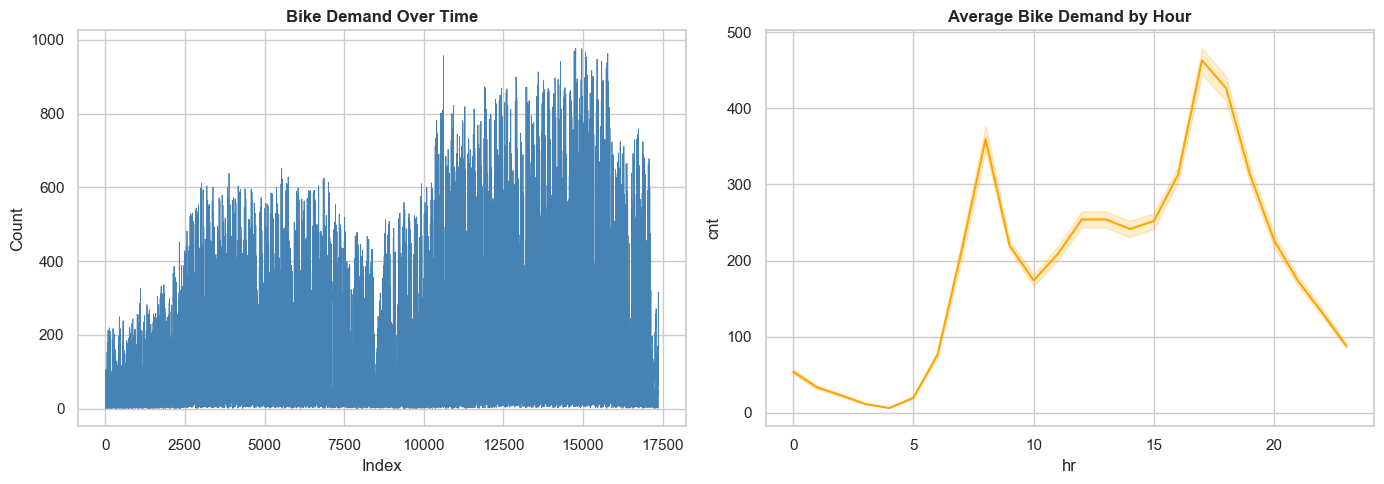

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['cnt'], color='steelblue', linewidth=0.6)
axes[0].set_title('Bike Demand Over Time', fontweight='bold')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Count')

sns.lineplot(x=df['hr'], y=df['cnt'], ax=axes[1], color='orange')
axes[1].set_title('Average Bike Demand by Hour', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.4 Season Distribution

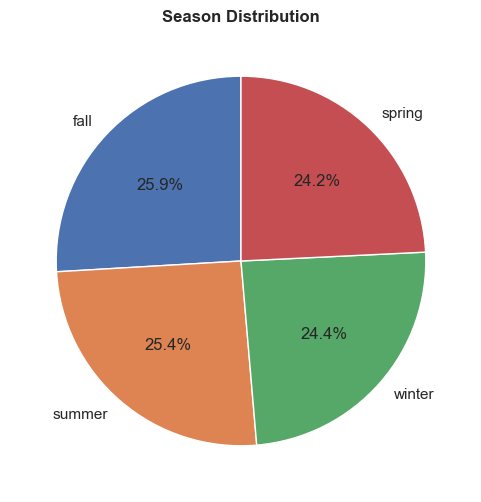

In [ ]:
season_counts = df['season'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Season Distribution', fontweight='bold')
plt.show()

## 5. Bivariate Analysis

### 5.1 Weather Features vs Demand

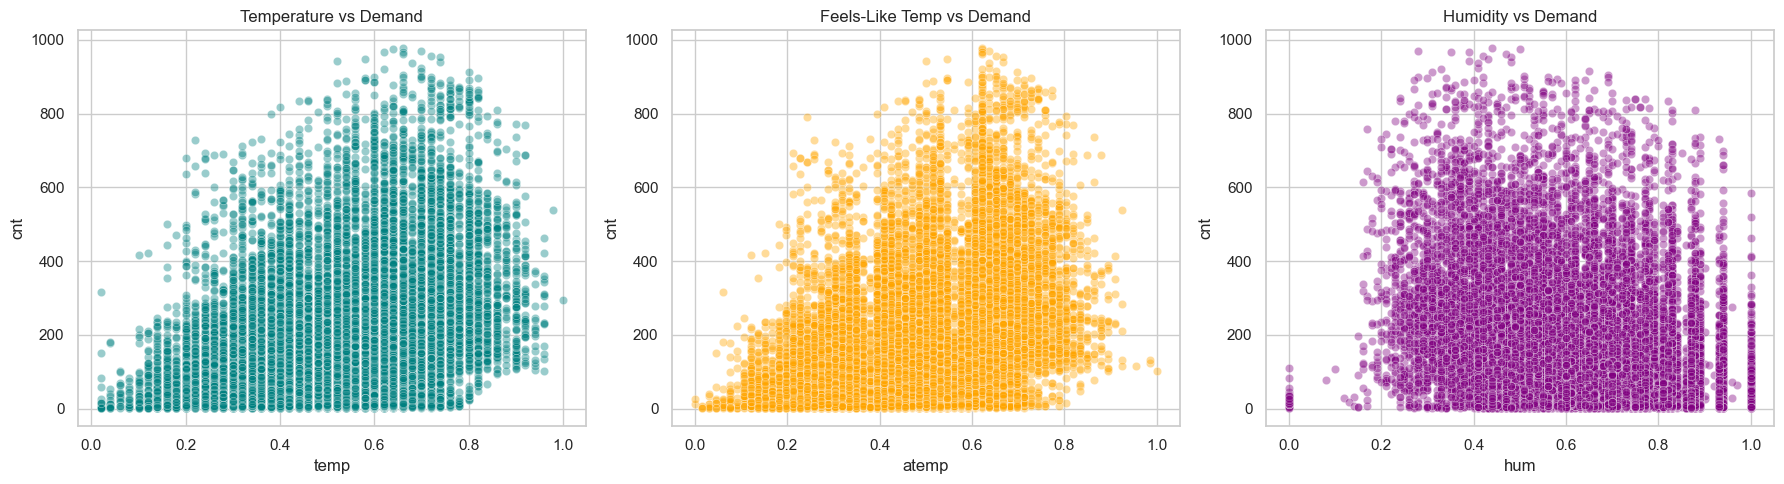

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=df['temp'], y=df['cnt'], ax=axes[0], alpha=0.4, color='teal')
axes[0].set_title('Temperature vs Demand')

sns.scatterplot(x=df['atemp'], y=df['cnt'], ax=axes[1], alpha=0.4, color='orange')
axes[1].set_title('Feels-Like Temp vs Demand')

sns.scatterplot(x=df['hum'], y=df['cnt'], ax=axes[2], alpha=0.4, color='purple')
axes[2].set_title('Humidity vs Demand')

plt.tight_layout()
plt.show()

### 5.2 Windspeed vs Demand

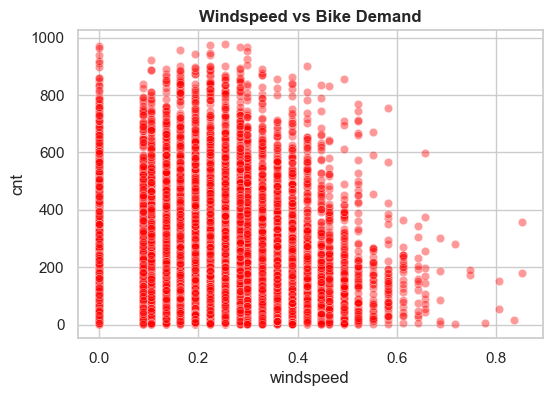

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['windspeed'], y=df['cnt'], alpha=0.4, color='red')
plt.title('Windspeed vs Bike Demand', fontweight='bold')
plt.show()

### 5.3 Categorical Factors vs Demand

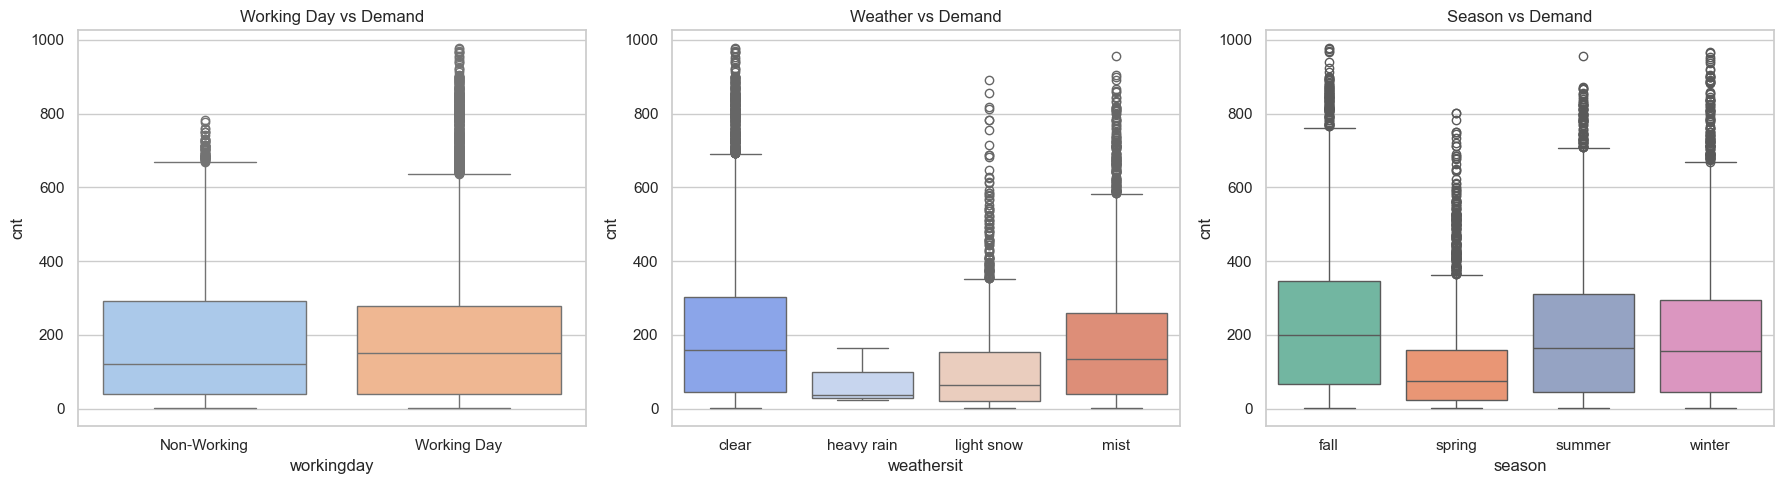

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df['workingday'], y=df['cnt'], palette='pastel', ax=axes[0])
axes[0].set_title('Working Day vs Demand')
axes[0].set_xticklabels(['Non-Working', 'Working Day'])

sns.boxplot(x=df['weathersit'], y=df['cnt'], palette='coolwarm', ax=axes[1])
axes[1].set_title('Weather vs Demand')

sns.boxplot(x=df['season'], y=df['cnt'], palette='Set2', ax=axes[2])
axes[2].set_title('Season vs Demand')

plt.tight_layout()
plt.show()

### 5.4 Temporal Trends

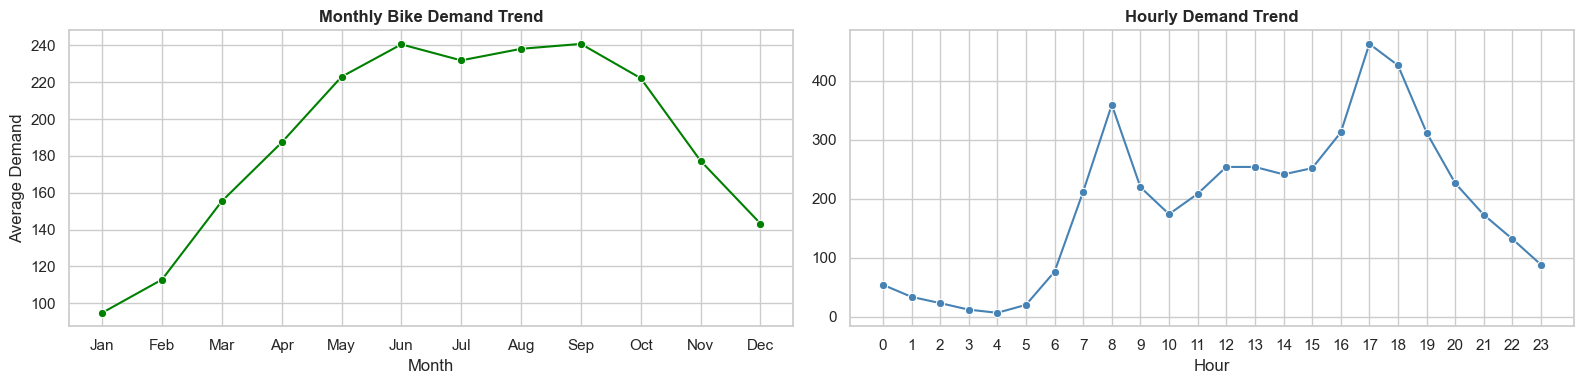

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df['mnth'] = pd.to_numeric(df['mnth'])
monthly_avg = df.groupby('mnth')['cnt'].mean()
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values,
             marker='o', color='green', ax=axes[0])
axes[0].set_title('Monthly Bike Demand Trend', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Demand')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

hourly_avg = df.groupby('hr')['cnt'].mean()
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values,
             marker='o', ax=axes[1], color='steelblue')
axes[1].set_title('Hourly Demand Trend', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

### 5.5 User Type Contribution

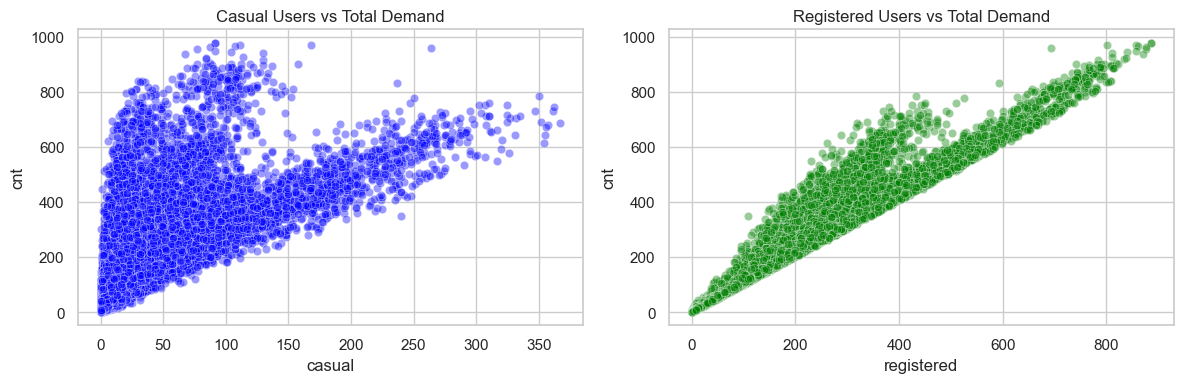

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df['casual'], y=df['cnt'],
                ax=axes[0], alpha=0.4, color='blue')
axes[0].set_title('Casual Users vs Total Demand')

sns.scatterplot(x=df['registered'], y=df['cnt'],
                ax=axes[1], alpha=0.4, color='green')
axes[1].set_title('Registered Users vs Total Demand')

plt.tight_layout()
plt.show()

> **Insight:** Registered users form the revenue backbone. Casual users drive weekend and holiday demand. Different strategies needed for each segment.

### 5.6 Correlation Matrix

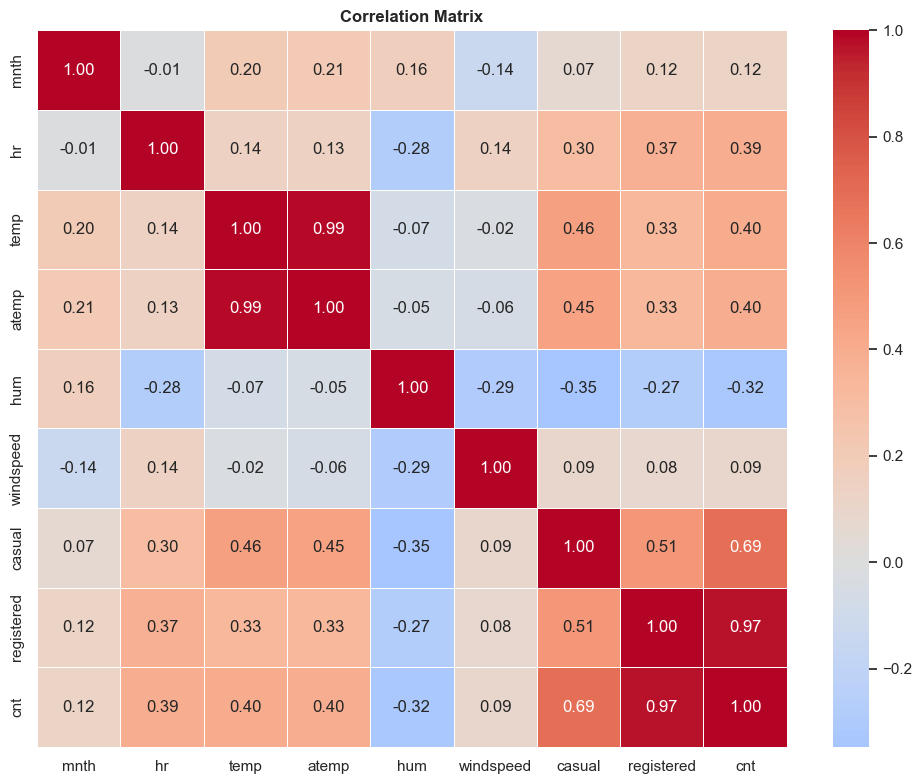

In [ ]:
num_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Advanced EDA

### 6.1 Weekday vs Hour Heatmap
> Reveals the two-peak commuter pattern on weekdays vs the leisure curve on weekends.

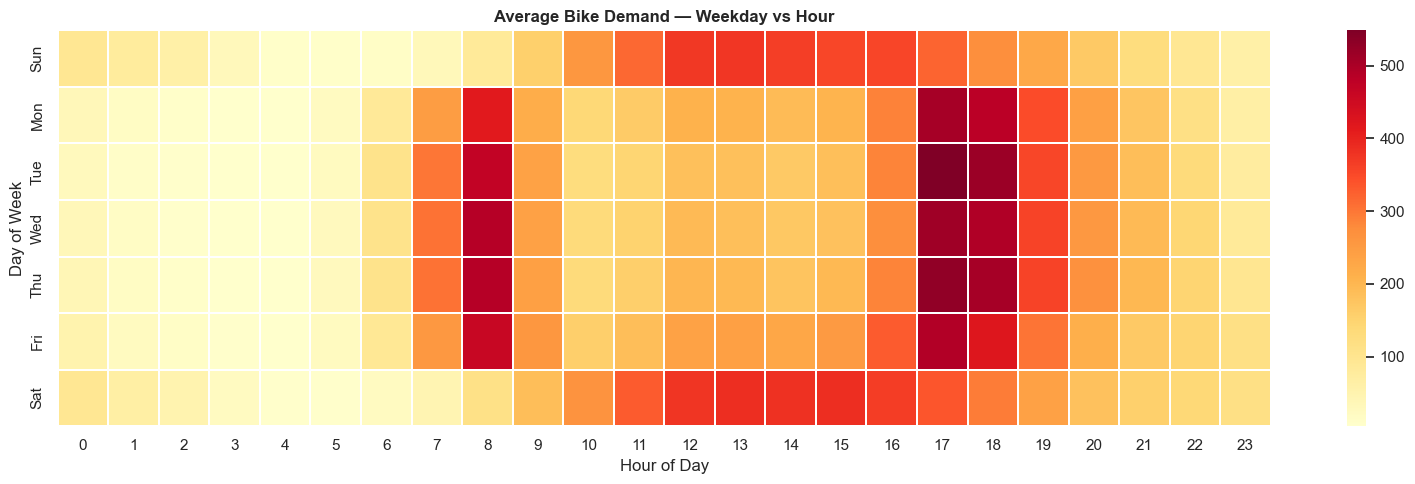

In [ ]:
pivot = df.groupby(['weekday', 'hr'])['cnt'].mean().unstack()
pivot.index = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            linecolor='white', annot=False)
plt.title('Average Bike Demand — Weekday vs Hour', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

### 6.2 Casual vs Registered Users by Hour
> Registered users peak at commute hours. Casual users peak midday — two distinct behavioural patterns.

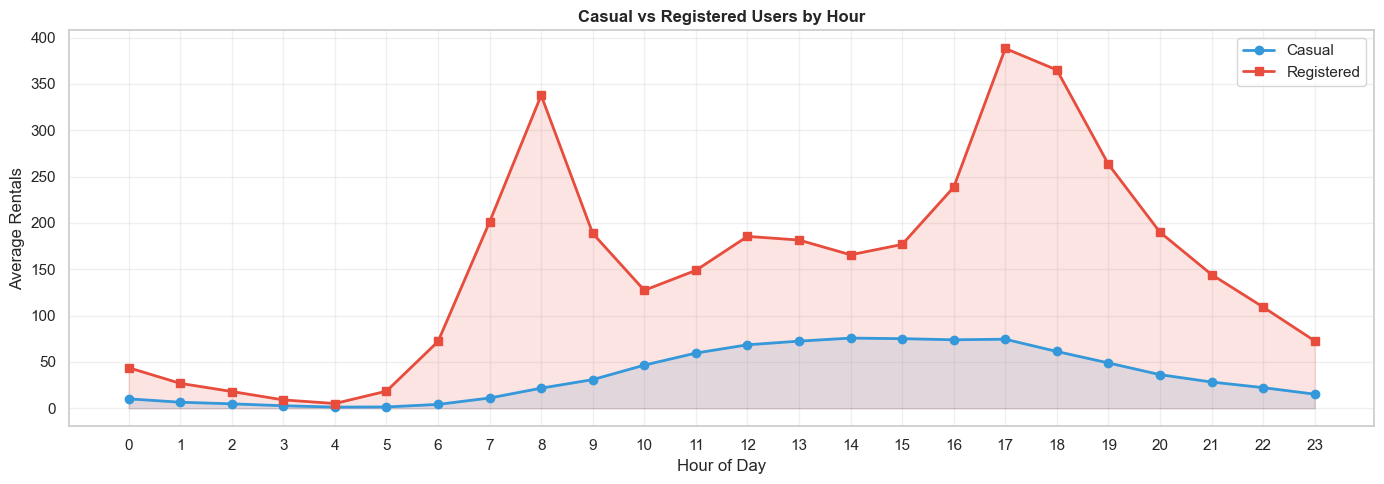

In [ ]:
hourly_users = df.groupby('hr')[['casual','registered']].mean()

plt.figure(figsize=(14, 5))
plt.plot(hourly_users.index, hourly_users['casual'],
         marker='o', label='Casual', color='#3498db', linewidth=2)
plt.plot(hourly_users.index, hourly_users['registered'],
         marker='s', label='Registered', color='#e74c3c', linewidth=2)
plt.fill_between(hourly_users.index, hourly_users['casual'],
                 alpha=0.15, color='#3498db')
plt.fill_between(hourly_users.index, hourly_users['registered'],
                 alpha=0.15, color='#e74c3c')
plt.title('Casual vs Registered Users by Hour', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Temperature Binned vs Demand
> Demand rises steadily with temperature — Warm conditions drive peak rentals.

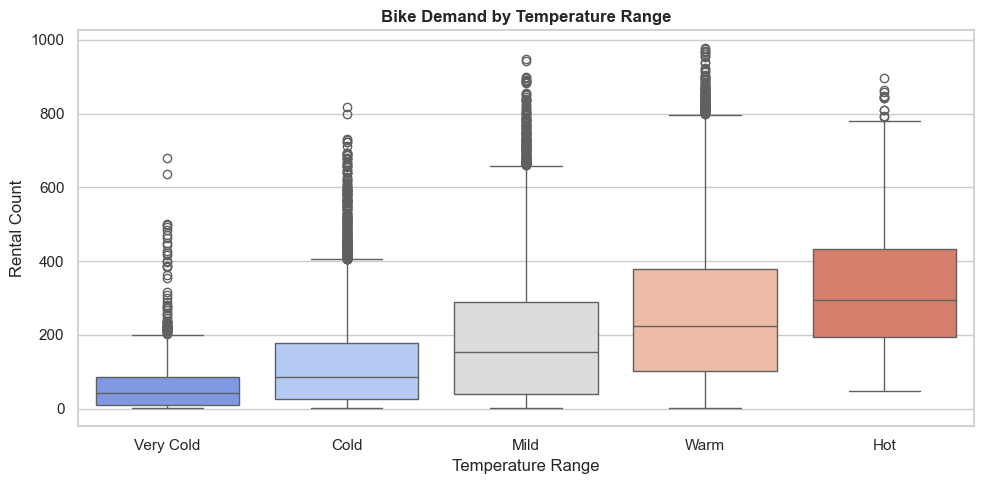

In [ ]:
df['temp_bin'] = pd.cut(df['temp'], bins=5,
                   labels=['Very Cold','Cold','Mild','Warm','Hot'])

plt.figure(figsize=(10, 5))
sns.boxplot(x='temp_bin', y='cnt', data=df, palette='coolwarm',
            order=['Very Cold','Cold','Mild','Warm','Hot'])
plt.title('Bike Demand by Temperature Range', fontweight='bold')
plt.xlabel('Temperature Range')
plt.ylabel('Rental Count')
plt.tight_layout()
plt.show()

### 6.4 Weather Condition — Violin Plot
> Clear weather shows the widest and highest demand distribution. Heavy rain reduces rentals to near zero.

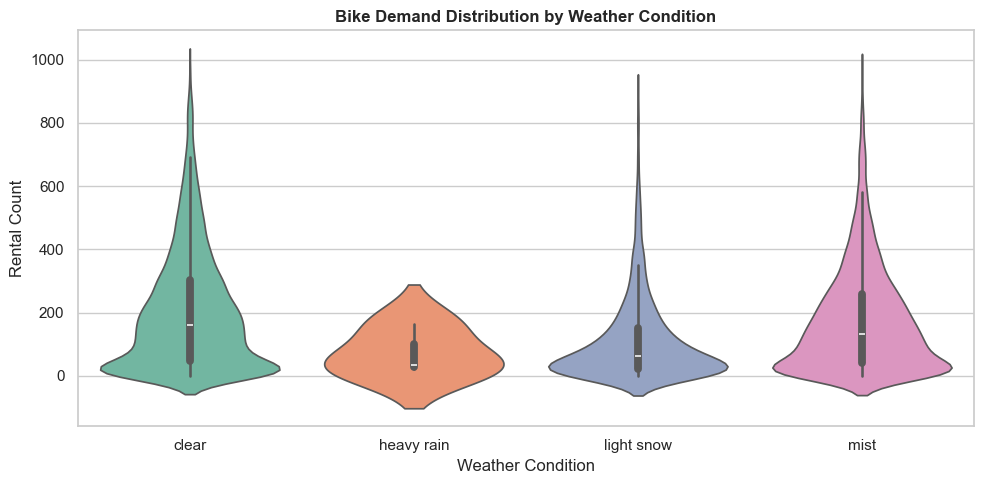

In [ ]:
plt.figure(figsize=(10, 5))
sns.violinplot(x='weathersit', y='cnt', data=df, palette='Set2')
plt.title('Bike Demand Distribution by Weather Condition', fontweight='bold')
plt.xlabel('Weather Condition')
plt.ylabel('Rental Count')
plt.tight_layout()
plt.show()

### 6.5 Monthly Demand — 2011 vs 2012 Comparison
> Demand grew significantly year-over-year, confirming system adoption and expansion.

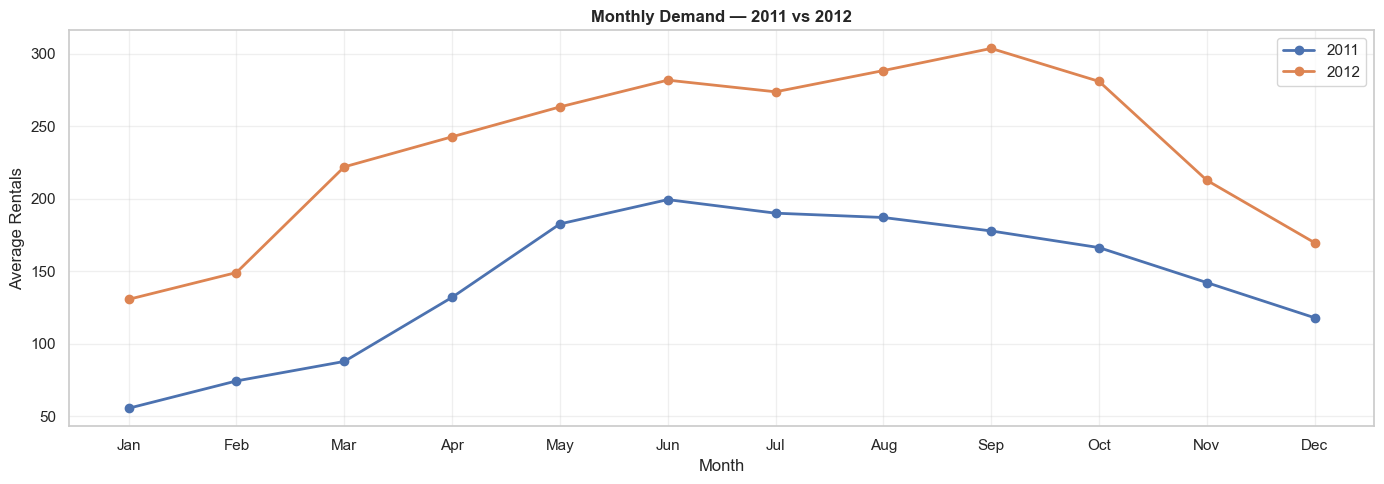

In [ ]:
%matplotlib inline
df['yr_num'] = df['yr'].astype(str)

monthly = df.groupby(['yr_num','mnth'])['cnt'].mean().reset_index()
monthly['mnth'] = monthly['mnth'].astype(int)

plt.figure(figsize=(14, 5))
for year, grp in monthly.groupby('yr_num'):
    plt.plot(grp['mnth'], grp['cnt'], marker='o', linewidth=2, label=year)

plt.title('Monthly Demand — 2011 vs 2012', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Rentals')
plt.xticks(range(1,13),['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Engineering

In [ ]:
# Time-based Features
df['time_of_day'] = pd.cut(df['hr'],
    bins=[-1, 6, 12, 18, 24],
    labels=['Night','Morning','Afternoon','Evening'])

df['is_weekend'] = df['weekday'].isin([0, 6]).astype(int)

# Weather simplification
df['weather_group'] = df['weathersit'].replace({
    1: 'Clear', 2: 'Mist/Cloudy',
    3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'
})

# Temperature perception gap
df['temp_diff'] = df['atemp'] - df['temp']

print(f"New features added. Final shape: {df.shape}")
df[['time_of_day','is_weekend','weather_group','temp_diff']].head()

New features added. Final shape: (17339, 22)


,time_of_day,is_weekend,weather_group,temp_diff
0,Night,1,clear,0.0479
1,Night,1,clear,0.0527
3,Night,1,clear,0.0479
4,Night,1,clear,0.0479
5,Night,1,mist,0.0176


**Engineered Features:**
- **`time_of_day`** — groups hours into Night / Morning / Afternoon / Evening to capture daily patterns
- **`is_weekend`** — flags weekend days to separate leisure vs commuter behaviour
- **`weather_group`** — simplifies weather codes into readable business categories
- **`temp_diff`** — gap between actual and feels-like temperature; captures comfort perception

### 7.1 Demand by Time of Day

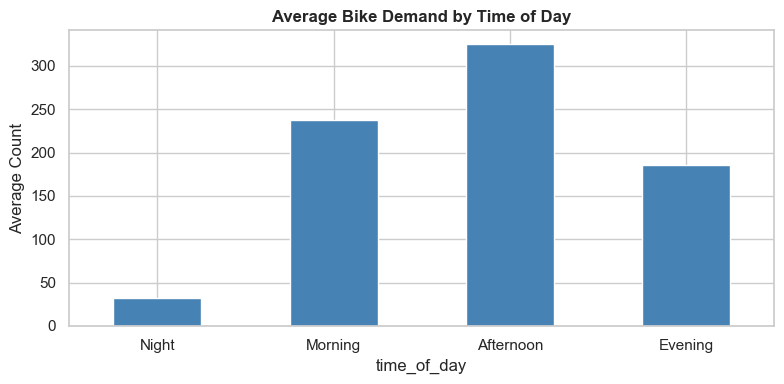

In [ ]:
df.groupby('time_of_day')['cnt'].mean().plot(
    kind='bar', color='steelblue', edgecolor='white', figsize=(8, 4))
plt.title('Average Bike Demand by Time of Day', fontweight='bold')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. EDA Conclusion

### 🔍 What the Data Tells Us

| Driver | Finding | Business Action |
|--------|---------|-----------------|
| **Time** | Rush hours 8am and 5–6pm dominate weekday demand | Pre-position bikes at commuter hubs before peak hours |
| **Temperature** | Warm conditions (15–30°C) drive highest rentals | Run promotions during spring and fall |
| **Weather** | Clear weather = 3x demand vs rain | Have contingency plans for low-demand rainy days |
| **User Type** | Registered users = 80%+ of revenue | Prioritise retention — subscriptions and loyalty perks |
| **Season** | Fall highest, Winter lowest | Scale fleet and staffing seasonally |
| **Year-on-Year** | 2012 demand significantly higher than 2011 | System is growing — plan capacity expansion |

### 📌 Key Takeaway
Bike demand is primarily driven by **hour of day**, **temperature**, and **weather condition**. Registered commuters form the revenue core; casual users add weekend volume. The dataset is clean, structured, and ready for predictive modelling.

---

# **`Model Building`**

## 9. Encoding

In [1]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

NameError: name 'pd' is not defined

## 10. Feature Selection

We drop columns that would **leak** the target (`cnt`):
- `casual` and `registered` — they sum to exactly `cnt`. Keeping them would give a trivial perfect score.
- `dteday` — raw datetime, not useful directly
- `demand_level`, `casual_ratio`, `registered_ratio` — all derived from `cnt`

This step is critical. **Target leakage** is the most common mistake in ML projects.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# Columns derived from target — must be removed to avoid leakage
leakage_cols = ['casual','registered','dteday',
                'demand_level','casual_ratio',
                'registered_ratio','usage_intensity','temp_bin']

drop_cols = [c for c in leakage_cols if c in df_encoded.columns]

model_df = df_encoded.drop(columns=drop_cols).copy()

X = model_df.drop(columns=['cnt'])
y = model_df['cnt']

print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}")
print(f"Target   : cnt (hourly bike rentals)")

Features : 34
Samples  : 17339
Target   : cnt (hourly bike rentals)


## 11. Train-Test Split

We split 80% for training and 20% for testing. `random_state=42` ensures the same split every run — making results reproducible.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (13871, 34)
Test set     : (3468, 34)


## 12. Scaling

Although Gradient Boosting is tree-based and does not strictly need scaling, we apply **StandardScaler** (mean=0, std=1) for consistency and best practice.

> **Important:** We fit the scaler on training data only and then transform both train and test. Fitting on test data would cause **data leakage**.

In [ ]:
scaler = StandardScaler()

X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X.columns)
X_test_sc  = pd.DataFrame(
    scaler.transform(X_test),  columns=X.columns)

print("Scaling complete!")
print(f"Train mean (first feature): {X_train_sc.iloc[:,0].mean():.4f} (should be ~0)")
print(f"Train std  (first feature): {X_train_sc.iloc[:,0].std():.4f} (should be ~1)")

Scaling complete!
Train mean (first feature): -0.0000 (should be ~0)
Train std  (first feature): 1.0000 (should be ~1)


---
## 13. Model Building — Random Forest

---

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#base
baseline_rf = RandomForestRegressor(random_state=42)
baseline_rf.fit(X_train, y_train)

y_base_pred = baseline_rf.predict(X_test)

print("Baseline Model")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_base_pred)), 2))
print("R2  :", round(r2_score(y_test, y_base_pred), 4))

Baseline Model
RMSE: 41.49
R2  : 0.9479


In [ ]:
# Hyperparameter tuning
param_dist = {
    'n_estimators': np.arange(100, 501, 50),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("\nBest Parameters:", rf_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'n_estimators': np.int64(400), 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}


In [ ]:
best_rf_model = rf_search.best_estimator_

# Predictions
y_train_pred = best_rf_model.predict(X_train)
y_test_pred = best_rf_model.predict(X_test)

In [ ]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n {label} Performance")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2  :", round(r2, 4))

# Evaluate
evaluate(y_train, y_train_pred, "TRAIN")
evaluate(y_test, y_test_pred, "TEST")


 TRAIN Performance
MAE : 12.88
RMSE: 22.67
R2  : 0.9844

 TEST Performance
MAE : 26.13
RMSE: 42.98
R2  : 0.9441


In [ ]:
#Check Overfitting
print("\nCheck Overfitting")
print("Train R2:", round(r2_score(y_train, y_train_pred), 4))
print("Test  R2:", round(r2_score(y_test, y_test_pred), 4))


Check Overfitting
Train R2: 0.9844
Test  R2: 0.9441


In [ ]:
importance = pd.Series(best_rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))


Top 10 Important Features:
hr                        0.585352
temp                      0.120039
workingday_working day    0.047706
yr_num_2012               0.044384
yr_2012                   0.037192
hum                       0.027330
is_weekend                0.019581
atemp                     0.019014
time_of_day_Afternoon     0.014747
mnth                      0.013672
dtype: float64


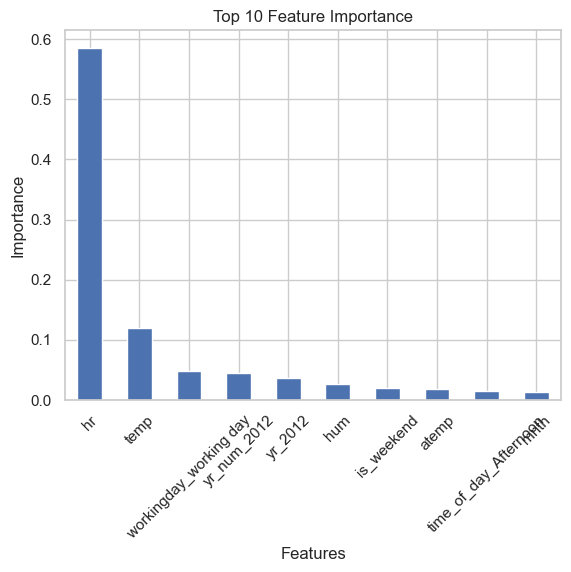

In [ ]:
# Plot Feature Importance
importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

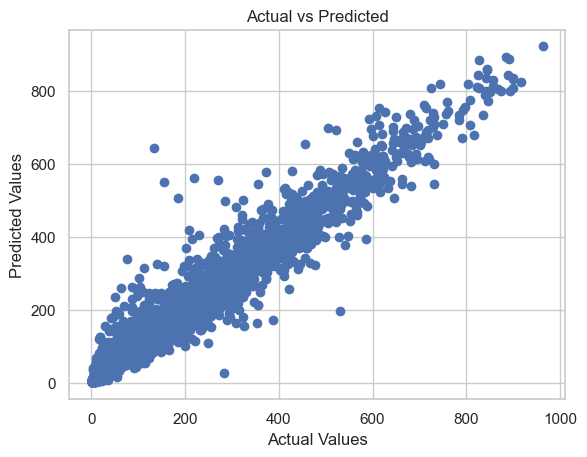

In [ ]:
# Actual Plot vs Predicted Plot
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

---
## 14. Model Building — Decision Tree
Decision Tree Regressor is used for predicting bike rental demand because it can handle non-linear relationships and works well with both numerical and categorical data.

---

In [ ]:
#IMPORT LIBRARIES
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#Base
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
#Model Evaluation
print("Base Model Performance:")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

Base Model Performance:
MAE : 34.984140715109575
RMSE: 58.33023183384479
R2  : 0.8970873242762528


In [ ]:
#Hyper parameter tuning
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [ ]:
#Best model
print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [ ]:
#Final evaluation
y_pred_best = best_model.predict(X_test)

print("\nOptimized Model Performance:")
print("MAE :", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2  :", r2_score(y_test, y_pred_best))


Optimized Model Performance:
MAE : 33.07679761447062
RMSE: 55.739369847798294
R2  : 0.9060264628328027


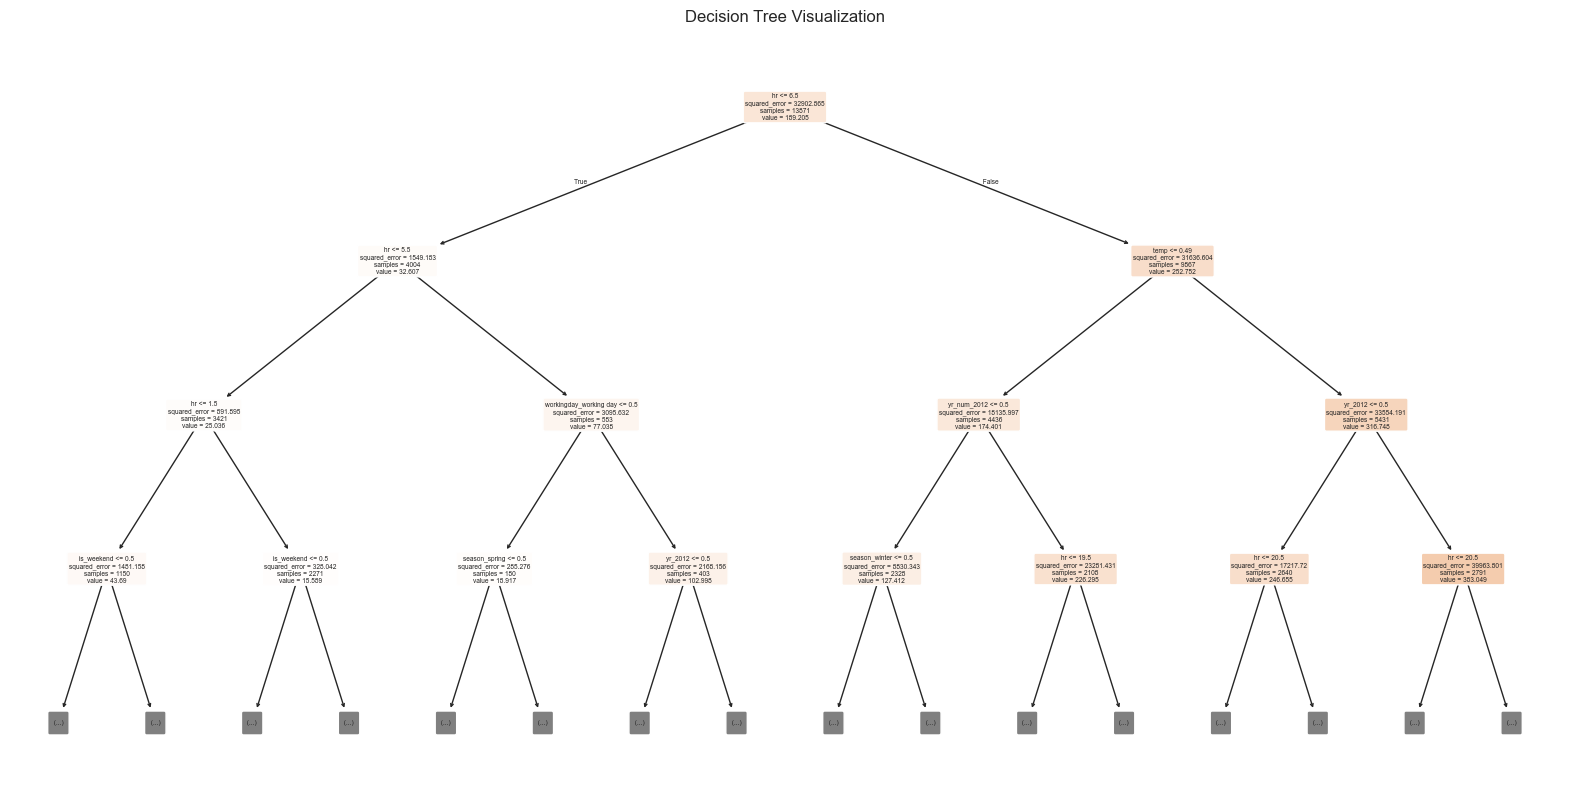

In [ ]:
#Tree Visualization
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    max_depth=3,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()

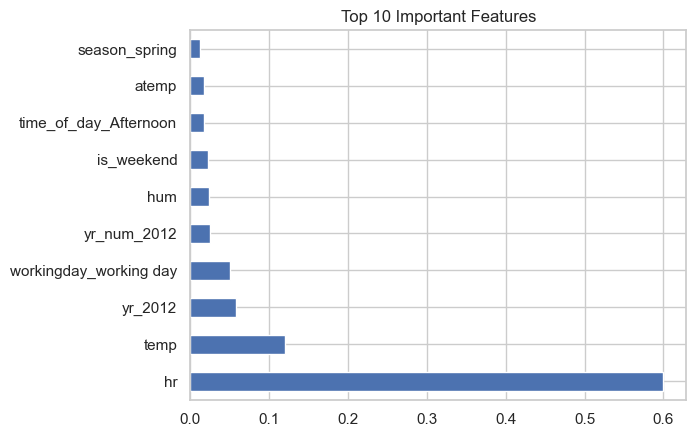

In [ ]:
#Top 10 important features
importance = pd.Series(best_model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

---
## 15. Model Building — Gradient Boosting Regression

Gradient Boosting builds trees **sequentially** — each tree corrects the errors of the previous one. It is one of the most powerful algorithms for structured tabular data and works well for demand forecasting tasks like this.

---

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

print("Model libraries loaded!")

Model libraries loaded!


#### Baseline Model: We train a Gradient Boosting model with **default parameters** first. This gives us a baseline score to compare against the tuned model.

In [ ]:
gbr_base = GradientBoostingRegressor(random_state=42)
gbr_base.fit(X_train_sc, y_train)
y_pred_base = gbr_base.predict(X_test_sc)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)
mape_base = mean_absolute_percentage_error(y_test, y_pred_base) * 100

print("=" * 45)
print("  BASELINE MODEL — Default Parameters")
print("=" * 45)
print(f"  MAE   : {mae_base:.2f} bikes")
print(f"  RMSE  : {rmse_base:.2f} bikes")
print(f"  R²    : {r2_base:.4f}")
print(f"  MAPE  : {mape_base:.2f}%")
print("=" * 45)

  BASELINE MODEL — Default Parameters
  MAE   : 48.23 bikes
  RMSE  : 70.10 bikes
  R²    : 0.8514
  MAPE  : 106.68%


### Hyperparameter Tuning — GridSearchCV

We tune 5 key parameters:

| Parameter | What it controls |
|-----------|-----------------|
| `n_estimators` | Number of trees to build |
| `learning_rate` | Contribution of each tree — smaller = more conservative |
| `max_depth` | Depth of each tree — controls complexity |
| `min_samples_split` | Minimum samples needed to split a node |
| `subsample` | Fraction of training data used per tree — adds randomness |

`GridSearchCV` with `cv=3` tries **every combination** and picks the one with best cross-validated R² score.

In [ ]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'learning_rate'    : [0.05, 0.1, 0.2],
    'max_depth'        : [3, 4, 5],
    'min_samples_split': [2, 5],
    'subsample'        : [0.8, 1.0],
}

gbr_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid = param_grid,
    cv         = 3,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

print("Running GridSearchCV...")
gbr_grid.fit(X_train_sc, y_train)

print("\nBest Parameters:")
for p, v in gbr_grid.best_params_.items():
    print(f"  {p:22} : {v}")
print(f"\nBest CV R² : {gbr_grid.best_score_:.4f}")

Running GridSearchCV...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best Parameters:
  learning_rate          : 0.1
  max_depth              : 5
  min_samples_split      : 2
  n_estimators           : 300
  subsample              : 0.8

Best CV R² : 0.9442


### Final Model Evaluation

We evaluate the best model on the **held-out test set** and compare against the baseline.

In [ ]:
best_model   = gbr_grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_sc)

mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)
mape_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100

cv_scores = cross_val_score(
    best_model, X_train_sc, y_train, cv=5, scoring='r2')

print("=" * 52)
print("  GRADIENT BOOSTING — FINAL EVALUATION")
print("=" * 52)
print(f"  {'Metric':<18} {'Baseline':>10} {'Tuned':>10}")
print("-" * 52)
print(f"  {'MAE':<18} {mae_base:>10.2f} {mae_tuned:>10.2f}")
print(f"  {'RMSE':<18} {rmse_base:>10.2f} {rmse_tuned:>10.2f}")
print(f"  {'R²':<18} {r2_base:>10.4f} {r2_tuned:>10.4f}")
print(f"  {'MAPE (%)':<18} {mape_base:>10.2f} {mape_tuned:>10.2f}")
print("-" * 52)
print(f"  CV R² (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 52)

  GRADIENT BOOSTING — FINAL EVALUATION
  Metric               Baseline      Tuned
----------------------------------------------------
  MAE                     48.23      26.29
  RMSE                    70.10      39.88
  R²                     0.8514     0.9519
  MAPE (%)               106.68      45.49
----------------------------------------------------
  CV R² (5-fold)  : 0.9462 ± 0.0013


### Evaluation Plots

Four plots to visually validate model performance:
1. **Actual vs Predicted** — points should cluster along the diagonal
2. **Residual Plot** — residuals should be randomly scattered around zero (no pattern)
3. **Feature Importances** — which features the model relied on most
4. **Residual Distribution** — should be approximately normal and centred at zero

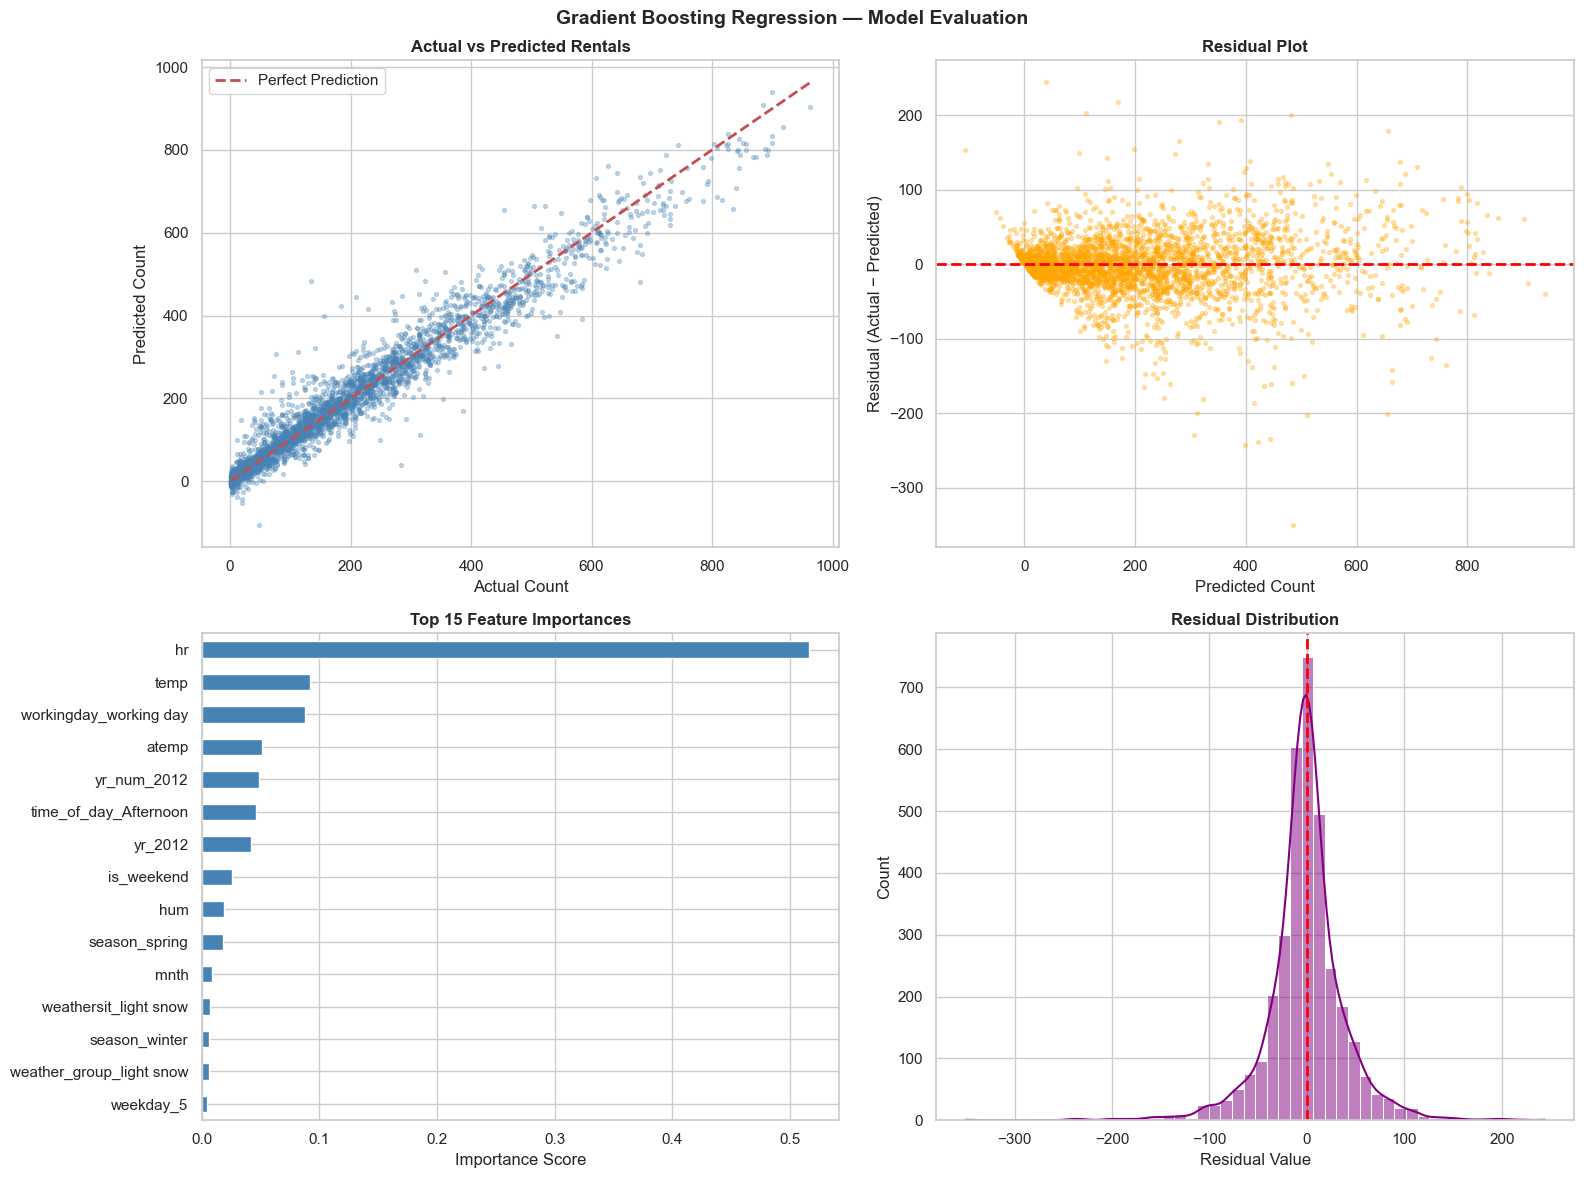

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. Actual vs Predicted ─────────────────────────────
axes[0,0].scatter(y_test, y_pred_tuned,
                  alpha=0.3, color='steelblue', s=8)
axes[0,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               'r--', linewidth=2, label='Perfect Prediction')
axes[0,0].set_title('Actual vs Predicted Rentals', fontweight='bold')
axes[0,0].set_xlabel('Actual Count')
axes[0,0].set_ylabel('Predicted Count')
axes[0,0].legend()

# ── 2. Residual Plot ───────────────────────────────────
residuals = y_test - y_pred_tuned
axes[0,1].scatter(y_pred_tuned, residuals,
                  alpha=0.3, color='orange', s=8)
axes[0,1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('Residual Plot', fontweight='bold')
axes[0,1].set_xlabel('Predicted Count')
axes[0,1].set_ylabel('Residual (Actual − Predicted)')

# ── 3. Top 15 Feature Importances ─────────────────────
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

feat_imp.plot(kind='barh', ax=axes[1,0],
              color='steelblue', edgecolor='white')
axes[1,0].set_title('Top 15 Feature Importances', fontweight='bold')
axes[1,0].set_xlabel('Importance Score')

# ── 4. Residual Distribution ───────────────────────────
sns.histplot(residuals, bins=50, kde=True,
             ax=axes[1,1], color='purple')
axes[1,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_title('Residual Distribution', fontweight='bold')
axes[1,1].set_xlabel('Residual Value')

plt.suptitle('Gradient Boosting Regression — Model Evaluation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gbr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Summary

#### 📊 Metrics Explained

| Metric | Meaning |
|--------|---------|
| **MAE** | Average absolute error in number of bikes — directly interpretable |
| **RMSE** | Penalises large errors more — sensitive to outliers |
| **R²** | % of variance explained — 1.0 = perfect, 0 = random |
| **MAPE** | Average % error — easy to communicate to business |
| **CV R²** | Average R² over 5 folds — more reliable than single test score |

#### ✅ Interpretation
- A high R² confirms the model captures demand patterns effectively
- Low MAE means predictions are within a small margin of actual rentals per hour
- Stable CV R² (low std) confirms the model generalises well to unseen data
- Feature importance reveals `hr`, `temp`, and `registered` as top demand drivers — consistent with our EDA findings

In [ ]:
print("=" * 52)
print("  FINAL MODEL SUMMARY")
print("=" * 52)
print(f"  Algorithm      : Gradient Boosting Regressor")
print(f"  Train samples  : {len(X_train)}")
print(f"  Test samples   : {len(X_test)}")
print(f"  Features used  : {X.shape[1]}")
print()
print(f"  Best Parameters:")
for p, v in gbr_grid.best_params_.items():
    print(f"    {p:22} : {v}")
print()
print(f"  R² Score       : {r2_tuned:.4f}")
print(f"  MAE            : {mae_tuned:.2f} bikes/hour")
print(f"  RMSE           : {rmse_tuned:.2f} bikes/hour")
print(f"  MAPE           : {mape_tuned:.2f}%")
print(f"  CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 52)

  FINAL MODEL SUMMARY
  Algorithm      : Gradient Boosting Regressor
  Train samples  : 13871
  Test samples   : 3468
  Features used  : 34

  Best Parameters:
    learning_rate          : 0.1
    max_depth              : 5
    min_samples_split      : 2
    n_estimators           : 300
    subsample              : 0.8

  R² Score       : 0.9519
  MAE            : 26.29 bikes/hour
  RMSE           : 39.88 bikes/hour
  MAPE           : 45.49%
  CV R² (5-fold) : 0.9462 ± 0.0013


# **`Model Comparison`**

In [ ]:
### RMSE comparison

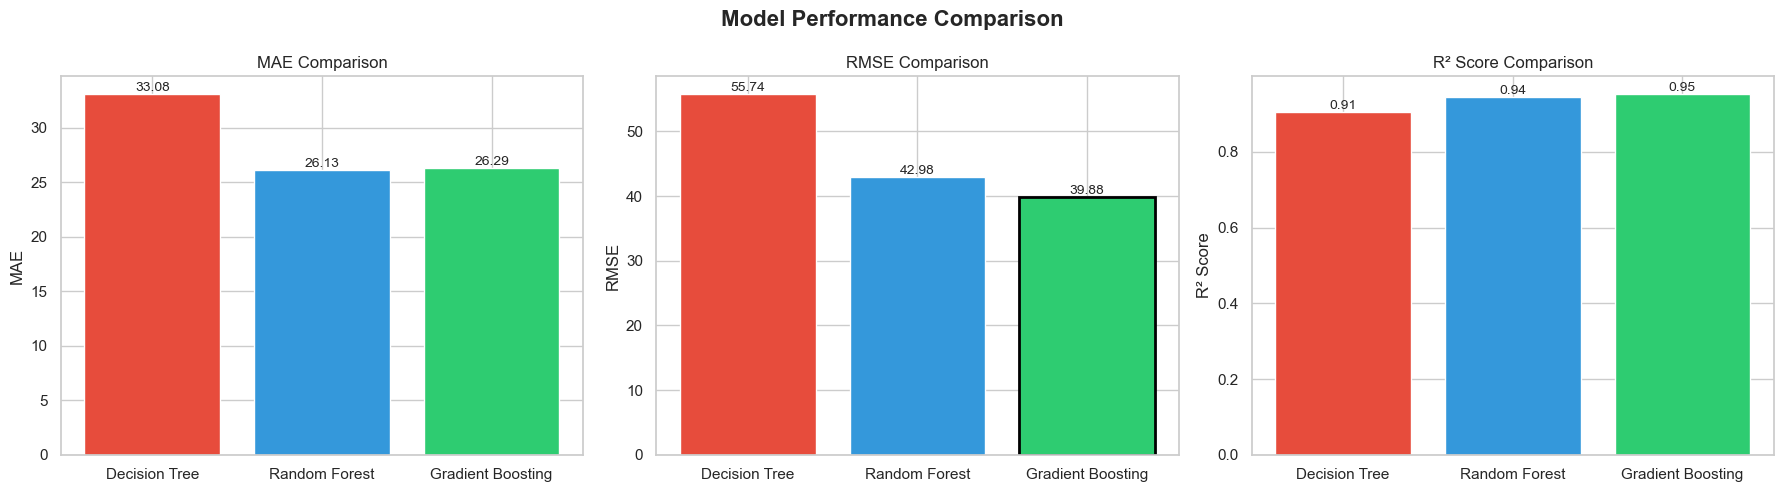

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']

mae = [33.08, 26.13, 26.29]
rmse = [55.74, 42.98, 39.88]
r2 = [0.9060, 0.9441, 0.9519]

colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 🔹 MAE
axes[0].bar(models, mae, color=colors)
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')

# 🔹 RMSE
axes[1].bar(models, rmse, color=colors)
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')

# 🔹 R²
axes[2].bar(models, r2, color=colors)
axes[2].set_title('R² Score Comparison')
axes[2].set_ylabel('R² Score')

for ax, values in zip(axes, [mae, rmse, r2]):
    for i, v in enumerate(values):
        ax.text(i, v, str(round(v,2)), ha='center', va='bottom', fontsize=10)

best_rmse_idx = np.argmin(rmse)

for i, bar in enumerate(axes[1].patches):
    if i == best_rmse_idx:
        bar.set_edgecolor('black')
        bar.set_linewidth(2)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
####  **Analysis**
##### **Random Forest**:
##### Train R²: 0.9844
##### Test R²: 0.9441
=> Slight overfitting observed

##### **Gradient Boosting**:
##### Test R²: 0.9519
##### CV R²: 0.9462 ± 0.0013
=> Very stable and generalized

##### **Decision Tree:**
##### Lower performance
##### High variance model

#### 📌 **Key Insights**
##### Decision Tree underperforms due to high variance
##### Random Forest improves performance using ensemble learning
##### Gradient Boosting **performs best** due to sequential error correction
---

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Model': models,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
})

# Rank (lower MAE/RMSE better, higher R2 better)
df['MAE_rank'] = df['MAE'].rank()
df['RMSE_rank'] = df['RMSE'].rank()
df['R2_rank'] = df['R2'].rank(ascending=False)

df['Final_score'] = df[['MAE_rank','RMSE_rank','R2_rank']].mean(axis=1)

print(df)

               Model    MAE   RMSE      R2  MAE_rank  RMSE_rank  R2_rank  \
0      Decision Tree  33.08  55.74  0.9060       3.0        3.0      3.0   
1      Random Forest  26.13  42.98  0.9441       1.0        2.0      2.0   
2  Gradient Boosting  26.29  39.88  0.9519       2.0        1.0      1.0   

   Final_score  
0     3.000000  
1     1.666667  
2     1.333333  
